In [ ]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY'] == "":
    raise ValueError("GOOGLE_API_KEY is not set in the .env file.")
else:
    print("GOOGLE_API_KEY is set correctly.")

GOOGLE_API_KEY is set correctly.


In [19]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash",)
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 3.5 Flash', 'release_date': '2026-05-19', 'last_updated': '2026-05-19', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.5-flash', temperature=1.0, client=<google.genai.client.Client object at 0x00000278092D52D0>, default_metadata=(), model_kwargs={})

In [23]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    name: str
    message: str

In [42]:
def welcome(schema: graph_schema) -> graph_schema:
    
    current_name = schema['name']
    current_message = schema['message']

    response = llm.invoke(f"My name is {current_name}. {current_message}. Please respond with a welcome message.").content[0].get('text')

    schema['message'] = response
    return schema

In [ ]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)
graph.add_node("welcome", welcome)
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

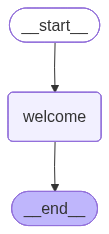

In [44]:
from IPython.display import Image, display

first_graph = graph.compile()
Image(first_graph.get_graph().draw_mermaid_png())

# print(first_graph.get_graph().draw_mermaid())  do this and paste the output in https://mermaid.live/ to visualize the graph

In [45]:
first_graph.invoke({"name": "Abid", "message": "How are you?"})

{'name': 'Abid',
 'message': 'Welcome, Abid! It is a pleasure to meet you. \n\nI am doing wonderful, thank you for asking. How can I assist you today?'}